# Disperser Performance Profiling

Goal: understand where time is spent in the star and galaxy dispersers to
guide optimization for 10K-object scenes.

We profile:
1. Individual operations (PSF interp, trace_beam, scatter-add, FFT convolve)
2. Full single-source dispersion
3. fori_loop overhead vs per-source cost
4. Scaling with source count

In [1]:
import os
from pathlib import Path
import time

import numpy as np
import jax
import jax.numpy as jnp
import jax.scipy.signal

from roman_disperser.optical_model import RomanOpticalModel
import roman_disperser.optical_model_jax as omj
import roman_disperser.star_disperser as star_disperser
import roman_disperser.galaxy_disperser as galaxy_disperser
import roman_disperser.psf_model as psf_model

print(f"JAX devices: {jax.devices()}")

JAX devices: [CudaDevice(id=0)]


In [2]:
# Setup — same config as the demo notebook
project_root = Path(os.environ.get("PIXI_PROJECT_ROOT", "."))
config_path = project_root / "data" / "Roman_grism_OpticalModel_v0.8.yaml"
cache_dir = project_root / "data" / "psf_cache"

SCA = 5
DETECTOR = 'WFI05'
ORDER = '1'
OVERSAMPLE = 4

# Wavelength grid
LAM_MIN, LAM_MAX = 0.9, 2.0
DLAM_UM = 2.0 / 1e4  # 2 Angstrom
n_wl = int((LAM_MAX - LAM_MIN) / DLAM_UM) + 1
wavelengths = jnp.linspace(LAM_MIN, LAM_MAX, n_wl, dtype=jnp.float32)

# Load model and payloads
model = RomanOpticalModel(config_file=str(config_path))
optical_payload = omj.make_sca_payload(model, sca=SCA, order=ORDER)
psf_payload = psf_model.get_or_make_psf_payload(
    detector=DETECTOR, order=ORDER, cache_dir=str(cache_dir), verbose=True
)

# Galaxy image (120x120 at 4x oversample)
from roman_disperser import demo_utils
galaxy_image = demo_utils.make_exponential_galaxy(
    npix=30, half_light_radius_arcsec=0.3, pixel_scale_arcsec=0.11,
    oversample=OVERSAMPLE, normalize=True,
)
galaxy_image_jax = jnp.array(np.array(galaxy_image, dtype=np.float32))

# Dummy flux (flat spectrum)
star_flux = jnp.ones(n_wl, dtype=jnp.float32)
output = jnp.zeros((4088, 4088), dtype=jnp.float32)

print(f"Wavelengths: {n_wl}, Galaxy image: {galaxy_image_jax.shape}")

Loading PSF payload from cache: /workspace/projects/roman_disperser/data/psf_cache/psf_WFI05_GRISM1_4x4x56_0.90-2.00um_fov5.0_os4.npz


Loaded PSF cache: /workspace/projects/roman_disperser/data/psf_cache/psf_WFI05_GRISM1_4x4x56_0.90-2.00um_fov5.0_os4.npz
  Detector: WFI05, Order: 1
  Grid shape: (4, 4, 56, 184, 184)
  Memory: 121.3 MB


Wavelengths: 5501, Galaxy image: (120, 120)


## 1. Profile Individual Operations

Time the key building blocks in isolation.

In [3]:
# --- 1a: PSF spatial interpolation ---
@jax.jit
def bench_psf_spatial(x, y):
    return psf_model.interpolate_psf_spatial(psf_payload, x, y)

# Warmup
_ = bench_psf_spatial(2000.0, 2000.0)
_.block_until_ready()

# Time
N = 100
t0 = time.perf_counter()
for _ in range(N):
    r = bench_psf_spatial(2000.0, 2000.0)
r.block_until_ready()
t_psf_spatial = (time.perf_counter() - t0) / N
print(f"PSF spatial interpolation: {t_psf_spatial*1e3:.3f} ms")
print(f"  Output shape: {r.shape}")

PSF spatial interpolation: 0.187 ms
  Output shape: (56, 184, 184)


In [4]:
# --- 1b: Dispersed position computation (trace_beam) ---
@jax.jit
def bench_trace(x, y, wl):
    return star_disperser._compute_dispersed_positions(optical_payload, x, y, wl)

_ = bench_trace(2000.0, 2000.0, wavelengths)
_[0].block_until_ready()

N = 100
t0 = time.perf_counter()
for _ in range(N):
    r = bench_trace(2000.0, 2000.0, wavelengths)
r[0].block_until_ready()
t_trace = (time.perf_counter() - t0) / N
print(f"trace_beam ({n_wl} wavelengths): {t_trace*1e3:.3f} ms")

trace_beam (5501 wavelengths): 0.158 ms


In [5]:
# --- 1c: Wavelength interpolation (1 chunk of 1000) ---
psfs_grid = psf_model.interpolate_psf_spatial(psf_payload, 2000.0, 2000.0)
grid_wl = psf_payload['wavelengths']
chunk_wl = wavelengths[:1000]

@jax.jit
def bench_wl_interp(grid, gwl, twl):
    return psf_model.interp_wavelength_chunk(grid, gwl, twl)

_ = bench_wl_interp(psfs_grid, grid_wl, chunk_wl)
_.block_until_ready()

N = 100
t0 = time.perf_counter()
for _ in range(N):
    r = bench_wl_interp(psfs_grid, grid_wl, chunk_wl)
r.block_until_ready()
t_wl_interp = (time.perf_counter() - t0) / N
print(f"Wavelength interp (1000 wl, PSF {psfs_grid.shape[1:]}): {t_wl_interp*1e3:.3f} ms")
print(f"  Output shape: {r.shape}, size: {r.nbytes/1e6:.1f} MB")

Wavelength interp (1000 wl, PSF (184, 184)): 0.192 ms
  Output shape: (1000, 184, 184), size: 135.4 MB


In [6]:
# --- 1d: Scatter-add (star-sized: 1000 wl x 184x184 PSF pixels) ---
psf_shape = psf_payload['psf_grid'].shape[-2:]
rel_y, rel_x = star_disperser.make_psf_pixel_grid(psf_shape, OVERSAMPLE)
n_psf = rel_x.size

# Create dummy scatter data
chunk_size = 1000
dummy_x = jnp.full(chunk_size, 2000.0) + jnp.linspace(-50, 50, chunk_size)  # spread across detector
dummy_y = jnp.full(chunk_size, 2000.0)
dummy_values = jnp.ones((chunk_size, n_psf), dtype=jnp.float32) * 1e-6

@jax.jit
def bench_scatter(output, x_chunk, y_chunk, values, rel_x_flat, rel_y_flat):
    det_x = x_chunk[:, None] + rel_x_flat[None, :]
    det_y = y_chunk[:, None] + rel_y_flat[None, :]
    idx_x = jnp.floor(det_x - 0.5).astype(jnp.int32).ravel()
    idx_y = jnp.floor(det_y - 0.5).astype(jnp.int32).ravel()
    vals = values.ravel()
    return output.at[idx_y, idx_x].add(vals, mode="drop", wrap_negative_indices=False)

_ = bench_scatter(output, dummy_x, dummy_y, dummy_values, rel_x.ravel(), rel_y.ravel())
_.block_until_ready()

N = 100
t0 = time.perf_counter()
for _ in range(N):
    r = bench_scatter(output, dummy_x, dummy_y, dummy_values, rel_x.ravel(), rel_y.ravel())
r.block_until_ready()
t_scatter_star = (time.perf_counter() - t0) / N
print(f"Scatter-add (star, {chunk_size} wl x {n_psf} pix = {chunk_size*n_psf/1e6:.1f}M ops): {t_scatter_star*1e3:.3f} ms")

Scatter-add (star, 1000 wl x 33856 pix = 33.9M ops): 0.619 ms


In [7]:
# --- 1e: FFT convolve (galaxy warped image x PSF, single wavelength) ---
psf_single = psfs_grid[28]  # mid-wavelength PSF

@jax.jit
def bench_fftconv(image, psf):
    return jax.scipy.signal.fftconvolve(image, psf, mode='full')

_ = bench_fftconv(galaxy_image_jax, psf_single)
_.block_until_ready()

N = 100
t0 = time.perf_counter()
for _ in range(N):
    r = bench_fftconv(galaxy_image_jax, psf_single)
r.block_until_ready()
t_fftconv = (time.perf_counter() - t0) / N
print(f"FFT convolve ({galaxy_image_jax.shape} x {psf_single.shape} -> {r.shape}): {t_fftconv*1e3:.3f} ms")

FFT convolve ((120, 120) x (184, 184) -> (303, 303)): 0.218 ms


In [8]:
# --- 1f: Jacobian + warp at single wavelength ---
@jax.jit
def bench_jac_warp(x0, y0, wl, image):
    dx = dy = 1.0 / OVERSAMPLE
    x_out, y_out, J = galaxy_disperser.trace_beam_sca_with_jacobian(
        optical_payload, x0, y0, wl
    )
    warped = galaxy_disperser.disperse_galaxy_shape(image, J, dx, dy)
    return warped, x_out, y_out

_ = bench_jac_warp(2000.0, 2000.0, 1.5, galaxy_image_jax)
_[0].block_until_ready()

N = 100
t0 = time.perf_counter()
for _ in range(N):
    r = bench_jac_warp(2000.0, 2000.0, 1.5, galaxy_image_jax)
r[0].block_until_ready()
t_jac_warp = (time.perf_counter() - t0) / N
print(f"Jacobian + warp (120x120): {t_jac_warp*1e3:.3f} ms")

Jacobian + warp (120x120): 0.138 ms


In [9]:
# --- 1g: prepare_galaxy_images (all 56 wl: Jacobian + warp + convolve) ---
@jax.jit
def bench_prepare(image, x0, y0):
    dx = dy = 1.0 / OVERSAMPLE
    return galaxy_disperser.prepare_galaxy_images(
        optical_payload, psf_payload, image, x0, y0, dx, dy
    )

_ = bench_prepare(galaxy_image_jax, 2000.0, 2000.0)
_[0].block_until_ready()

N = 50
t0 = time.perf_counter()
for _ in range(N):
    r = bench_prepare(galaxy_image_jax, 2000.0, 2000.0)
r[0].block_until_ready()
t_prepare = (time.perf_counter() - t0) / N
print(f"prepare_galaxy_images (56 wl: jac+warp+convolve): {t_prepare*1e3:.3f} ms")
print(f"  Output shape: {r[0].shape}, size: {r[0].nbytes/1e6:.1f} MB")

prepare_galaxy_images (56 wl: jac+warp+convolve): 0.720 ms
  Output shape: (56, 303, 303), size: 20.6 MB


In [10]:
# --- 1h: Scatter-add (galaxy-sized: 500 wl x 303x303 convolved pixels) ---
conv_shape = (galaxy_image_jax.shape[0] + psf_shape[0] - 1,
              galaxy_image_jax.shape[1] + psf_shape[1] - 1)
n_conv = conv_shape[0] * conv_shape[1]
rel_y_g, rel_x_g = star_disperser.make_psf_pixel_grid(conv_shape, OVERSAMPLE)

chunk_size_g = 500
dummy_x_g = jnp.full(chunk_size_g, 2000.0) + jnp.linspace(-50, 50, chunk_size_g)
dummy_y_g = jnp.full(chunk_size_g, 2000.0)
dummy_values_g = jnp.ones((chunk_size_g, n_conv), dtype=jnp.float32) * 1e-6

@jax.jit
def bench_scatter_gal(output, x_chunk, y_chunk, values, rel_x_flat, rel_y_flat):
    det_x = x_chunk[:, None] + rel_x_flat[None, :]
    det_y = y_chunk[:, None] + rel_y_flat[None, :]
    idx_x = jnp.floor(det_x - 0.5).astype(jnp.int32).ravel()
    idx_y = jnp.floor(det_y - 0.5).astype(jnp.int32).ravel()
    vals = values.ravel()
    return output.at[idx_y, idx_x].add(vals, mode="drop", wrap_negative_indices=False)

_ = bench_scatter_gal(output, dummy_x_g, dummy_y_g, dummy_values_g, rel_x_g.ravel(), rel_y_g.ravel())
_.block_until_ready()

N = 50
t0 = time.perf_counter()
for _ in range(N):
    r = bench_scatter_gal(output, dummy_x_g, dummy_y_g, dummy_values_g, rel_x_g.ravel(), rel_y_g.ravel())
r.block_until_ready()
t_scatter_gal = (time.perf_counter() - t0) / N
print(f"Scatter-add (galaxy, {chunk_size_g} wl x {n_conv} pix = {chunk_size_g*n_conv/1e6:.1f}M ops): {t_scatter_gal*1e3:.3f} ms")

Scatter-add (galaxy, 500 wl x 91809 pix = 45.9M ops): 0.625 ms


In [11]:
# --- Summary of individual operations ---
print("=" * 65)
print("INDIVIDUAL OPERATION TIMINGS")
print("=" * 65)
print(f"{'Operation':<45} {'Time (ms)':>10}")
print("-" * 65)
print(f"{'PSF spatial interpolation':<45} {t_psf_spatial*1e3:>10.3f}")
print(f"{'trace_beam (5501 wl)':<45} {t_trace*1e3:>10.3f}")
print(f"{'Wavelength interp (1000 PSFs)':<45} {t_wl_interp*1e3:>10.3f}")
print(f"{'Scatter-add (star, 1000 wl x 33K pix)':<45} {t_scatter_star*1e3:>10.3f}")
print(f"{'FFT convolve (120x120 * 184x184)':<45} {t_fftconv*1e3:>10.3f}")
print(f"{'Jacobian + warp (120x120)':<45} {t_jac_warp*1e3:>10.3f}")
print(f"{'prepare_galaxy_images (56 wl, all ops)':<45} {t_prepare*1e3:>10.3f}")
print(f"{'Scatter-add (galaxy, 500 wl x 92K pix)':<45} {t_scatter_gal*1e3:>10.3f}")
print("=" * 65)

# Estimate time breakdown for star disperser (6 chunks of 1000)
n_star_chunks = 6
star_est = t_psf_spatial + t_trace + n_star_chunks * (t_wl_interp + t_scatter_star)
print(f"\nStar disperser estimate: {star_est*1e3:.1f} ms")
print(f"  PSF spatial:  {t_psf_spatial/star_est*100:5.1f}%")
print(f"  trace_beam:   {t_trace/star_est*100:5.1f}%")
print(f"  wl interp:    {n_star_chunks*t_wl_interp/star_est*100:5.1f}% (6 chunks)")
print(f"  scatter-add:  {n_star_chunks*t_scatter_star/star_est*100:5.1f}% (6 chunks)")

# Estimate time breakdown for galaxy disperser (11 chunks of 500)
n_gal_chunks = 11
gal_est = t_prepare + t_trace + n_gal_chunks * (t_wl_interp + t_scatter_gal)
print(f"\nGalaxy disperser estimate: {gal_est*1e3:.1f} ms")
print(f"  prepare (jac+warp+conv):  {t_prepare/gal_est*100:5.1f}%")
print(f"  trace_beam:               {t_trace/gal_est*100:5.1f}%")
print(f"  wl interp:                {n_gal_chunks*t_wl_interp/gal_est*100:5.1f}% (11 chunks)")
print(f"  scatter-add:              {n_gal_chunks*t_scatter_gal/gal_est*100:5.1f}% (11 chunks)")

INDIVIDUAL OPERATION TIMINGS
Operation                                      Time (ms)
-----------------------------------------------------------------
PSF spatial interpolation                          0.187
trace_beam (5501 wl)                               0.158
Wavelength interp (1000 PSFs)                      0.192
Scatter-add (star, 1000 wl x 33K pix)              0.619
FFT convolve (120x120 * 184x184)                   0.218
Jacobian + warp (120x120)                          0.138
prepare_galaxy_images (56 wl, all ops)             0.720
Scatter-add (galaxy, 500 wl x 92K pix)             0.625

Star disperser estimate: 5.2 ms
  PSF spatial:    3.6%
  trace_beam:     3.0%
  wl interp:     22.1% (6 chunks)
  scatter-add:   71.3% (6 chunks)

Galaxy disperser estimate: 9.9 ms
  prepare (jac+warp+conv):    7.3%
  trace_beam:                 1.6%
  wl interp:                 21.4% (11 chunks)
  scatter-add:               69.7% (11 chunks)


## 2. Full Single-Source Dispersion

Time the complete disperser for a single star and galaxy.

In [12]:
# Create dispersers
star_disp = star_disperser.make_star_disperser(psf_payload, optical_payload)
gal_disp = galaxy_disperser.make_galaxy_disperser(psf_payload, optical_payload)

# Warmup
_ = star_disp(2000.0, 2000.0, wavelengths, star_flux, output)
_.block_until_ready()
_ = gal_disp(galaxy_image_jax, 2000.0, 2000.0, star_flux, wavelengths, output)
_.block_until_ready()

# Time single star
N = 50
t0 = time.perf_counter()
for _ in range(N):
    r = star_disp(2000.0, 2000.0, wavelengths, star_flux, output)
r.block_until_ready()
t_star_single = (time.perf_counter() - t0) / N

# Time single galaxy
N = 50
t0 = time.perf_counter()
for _ in range(N):
    r = gal_disp(galaxy_image_jax, 2000.0, 2000.0, star_flux, wavelengths, output)
r.block_until_ready()
t_gal_single = (time.perf_counter() - t0) / N

print(f"Single star dispersion:  {t_star_single*1e3:.1f} ms")
print(f"Single galaxy dispersion: {t_gal_single*1e3:.1f} ms")

Single star dispersion:  3.6 ms
Single galaxy dispersion: 7.8 ms


## 3. fori_loop Scaling

Measure how wall time scales with number of sources in fori_loop.
If per-source time is constant, the overhead is small.
If there's a fixed overhead that dominates, batching will help.

In [13]:
# Scaling test: fori_loop with varying source counts
# Use random positions for realistic scatter patterns
rng = np.random.default_rng(42)
max_sources = 256
all_x = jnp.array(rng.uniform(100, 3988, size=max_sources).astype(np.float32))
all_y = jnp.array(rng.uniform(100, 3988, size=max_sources).astype(np.float32))
all_flux = jnp.ones((max_sources, n_wl), dtype=jnp.float32)

star_disp_fn = star_disperser.make_star_disperser(psf_payload, optical_payload)

def make_star_fori(n, xs, ys, fluxes):
    """Make a fori_loop function for n stars."""
    @jax.jit
    def run(output):
        def body(i, out):
            return star_disp_fn(xs[i], ys[i], wavelengths, fluxes[i], out)
        return jax.lax.fori_loop(0, n, body, output)
    return run

source_counts = [1, 2, 4, 8, 16, 32, 64, 128, 256]
star_times = []

for n in source_counts:
    fn = make_star_fori(n, all_x, all_y, all_flux)
    # Warmup (triggers recompilation for each n)
    r = fn(output)
    r.block_until_ready()
    # Time
    repeats = max(3, 30 // n)
    t0 = time.perf_counter()
    for _ in range(repeats):
        r = fn(output)
    r.block_until_ready()
    elapsed = (time.perf_counter() - t0) / repeats
    per_source = elapsed / n
    star_times.append(elapsed)
    print(f"  {n:>4d} stars: {elapsed*1e3:8.1f} ms total, {per_source*1e3:6.2f} ms/star")

     1 stars:      3.6 ms total,   3.62 ms/star


     2 stars:      6.8 ms total,   3.40 ms/star


     4 stars:     13.0 ms total,   3.26 ms/star


     8 stars:     26.8 ms total,   3.36 ms/star


    16 stars:     50.2 ms total,   3.14 ms/star


    32 stars:     99.8 ms total,   3.12 ms/star


    64 stars:    201.5 ms total,   3.15 ms/star


   128 stars:    407.4 ms total,   3.18 ms/star


   256 stars:    809.3 ms total,   3.16 ms/star


In [14]:
# Same scaling test for galaxies
gal_disp_fn = galaxy_disperser.make_galaxy_disperser(psf_payload, optical_payload)

def make_gal_fori(n, xs, ys, fluxes, image):
    @jax.jit
    def run(output):
        def body(i, out):
            return gal_disp_fn(image, xs[i], ys[i], fluxes[i], wavelengths, out)
        return jax.lax.fori_loop(0, n, body, output)
    return run

gal_counts = [1, 2, 4, 8, 16, 32, 64, 128, 256]
gal_times = []

for n in gal_counts:
    fn = make_gal_fori(n, all_x, all_y, all_flux, galaxy_image_jax)
    r = fn(output)
    r.block_until_ready()
    repeats = max(3, 30 // n)
    t0 = time.perf_counter()
    for _ in range(repeats):
        r = fn(output)
    r.block_until_ready()
    elapsed = (time.perf_counter() - t0) / repeats
    per_source = elapsed / n
    gal_times.append(elapsed)
    print(f"  {n:>4d} galaxies: {elapsed*1e3:8.1f} ms total, {per_source*1e3:6.2f} ms/galaxy")

     1 galaxies:      8.2 ms total,   8.15 ms/galaxy


     2 galaxies:     15.5 ms total,   7.75 ms/galaxy


     4 galaxies:     29.5 ms total,   7.37 ms/galaxy


     8 galaxies:     61.8 ms total,   7.73 ms/galaxy


    16 galaxies:    115.0 ms total,   7.19 ms/galaxy


    32 galaxies:    232.7 ms total,   7.27 ms/galaxy


    64 galaxies:    475.6 ms total,   7.43 ms/galaxy


   128 galaxies:    962.9 ms total,   7.52 ms/galaxy


   256 galaxies:   1914.9 ms total,   7.48 ms/galaxy


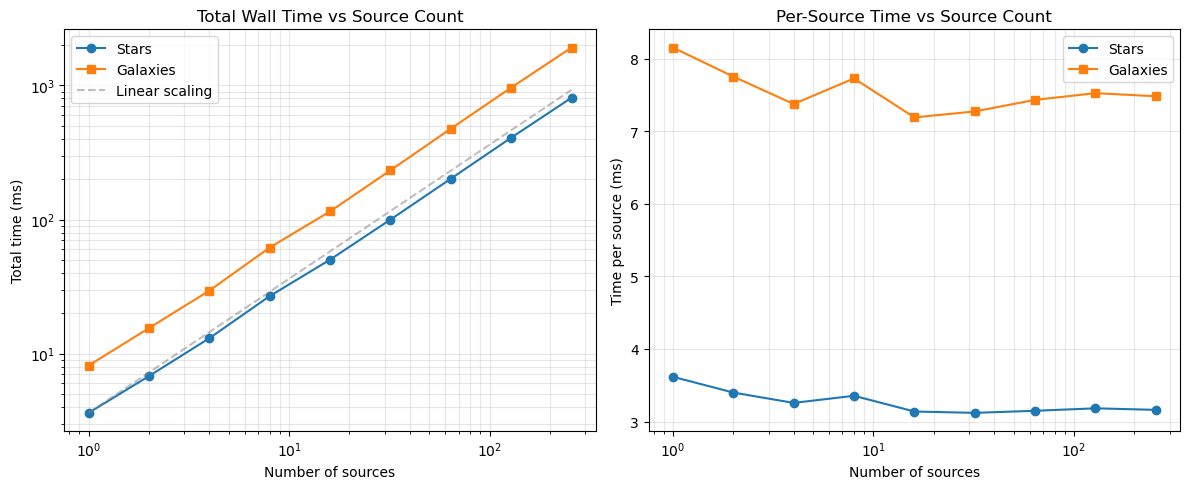

In [15]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Total time
axes[0].loglog(source_counts, [t*1e3 for t in star_times], 'o-', label='Stars')
axes[0].loglog(gal_counts, [t*1e3 for t in gal_times], 's-', label='Galaxies')
# Reference line: perfect linear scaling from N=1
axes[0].loglog(source_counts, [star_times[0]*1e3*n for n in source_counts],
               '--', color='gray', alpha=0.5, label='Linear scaling')
axes[0].set(xlabel='Number of sources', ylabel='Total time (ms)',
            title='Total Wall Time vs Source Count')
axes[0].legend()
axes[0].grid(True, alpha=0.3, which='both')

# Per-source time
axes[1].semilogx(source_counts, [t/n*1e3 for t, n in zip(star_times, source_counts)],
                 'o-', label='Stars')
axes[1].semilogx(gal_counts, [t/n*1e3 for t, n in zip(gal_times, gal_counts)],
                 's-', label='Galaxies')
axes[1].set(xlabel='Number of sources', ylabel='Time per source (ms)',
            title='Per-Source Time vs Source Count')
axes[1].legend()
axes[1].grid(True, alpha=0.3, which='both')

plt.tight_layout()
plt.show()

In [16]:
# Extrapolate to 10K sources
# Use the per-source rate from the largest batch
star_rate = star_times[-1] / source_counts[-1]  # s/star
gal_rate = gal_times[-1] / gal_counts[-1]       # s/galaxy

n_target = 10000
n_orders = 3

print(f"Extrapolation to {n_target} sources x {n_orders} orders:")
print(f"  Stars:    {star_rate*1e3:.2f} ms/star   -> {n_target * n_orders * star_rate:.0f}s ({n_target * n_orders * star_rate / 60:.1f} min)")
print(f"  Galaxies: {gal_rate*1e3:.2f} ms/galaxy -> {n_target * n_orders * gal_rate:.0f}s ({n_target * n_orders * gal_rate / 60:.1f} min)")
print(f"  Total:    {n_target * n_orders * (star_rate + gal_rate):.0f}s ({n_target * n_orders * (star_rate + gal_rate) / 60:.1f} min)")

Extrapolation to 10000 sources x 3 orders:
  Stars:    3.16 ms/star   -> 95s (1.6 min)
  Galaxies: 7.48 ms/galaxy -> 224s (3.7 min)
  Total:    319s (5.3 min)


## 4. Kernel Launch Overhead Test

Compare calling the disperser N times from Python (N kernel launches)
vs a single fori_loop call (1 kernel launch). The difference reveals
how much is kernel launch overhead.

In [17]:
# Python loop: N separate kernel launches
N_test = 32

# Ensure warmup
r = star_disp(all_x[0], all_y[0], wavelengths, all_flux[0], output)
r.block_until_ready()

# Python loop
t0 = time.perf_counter()
out = output
for i in range(N_test):
    out = star_disp(all_x[i], all_y[i], wavelengths, all_flux[i], out)
out.block_until_ready()
t_python_loop = time.perf_counter() - t0

# fori_loop: 1 kernel launch
fn_fori = make_star_fori(N_test, all_x, all_y, all_flux)
r = fn_fori(output)
r.block_until_ready()

t0 = time.perf_counter()
r = fn_fori(output)
r.block_until_ready()
t_fori_loop = time.perf_counter() - t0

print(f"{N_test} stars:")
print(f"  Python loop: {t_python_loop*1e3:.1f} ms ({t_python_loop/N_test*1e3:.2f} ms/star)")
print(f"  fori_loop:   {t_fori_loop*1e3:.1f} ms ({t_fori_loop/N_test*1e3:.2f} ms/star)")
print(f"  Ratio:       {t_python_loop/t_fori_loop:.2f}x")
print(f"  Overhead per kernel launch: ~{(t_python_loop - t_fori_loop)/N_test*1e3:.2f} ms")

32 stars:
  Python loop: 115.0 ms (3.59 ms/star)
  fori_loop:   103.8 ms (3.24 ms/star)
  Ratio:       1.11x
  Overhead per kernel launch: ~0.35 ms
